# Exploración y Análisis del Dataset de Clasificación de Setas (Dataset Secundario)

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency

## Carga del dataset

In [2]:
BASE_DIR = Path().resolve().parent
data_path = BASE_DIR / "data" / "secondary_data.csv"
df = pd.read_csv(data_path, sep=";")
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


## Exploración inicial

In [3]:
df.shape

(61069, 21)

El conjunto de datos está formado por 61.069 observaciones y 21 variables. Cada fila representa una seta con sus características morfológicas y ambientales, mientras que las columnas incluyen tanto las variables predictoras como la variable objetivo que indica si la seta es comestible o venenosa.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  str    
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  str    
 3   cap-surface           46949 non-null  str    
 4   cap-color             61069 non-null  str    
 5   does-bruise-or-bleed  61069 non-null  str    
 6   gill-attachment       51185 non-null  str    
 7   gill-spacing          36006 non-null  str    
 8   gill-color            61069 non-null  str    
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   str    
 12  stem-surface          22945 non-null  str    
 13  stem-color            61069 non-null  str    
 14  veil-type             3177 non-null   str    
 15  veil-color            7413 non

La mayoría de las variables del dataset son de tipo categórico (18 de 21), mientras que únicamente tres son numéricas (cap-diameter, stem-height y stem-width). Asimismo, algunas características presentan un elevado porcentaje de valores ausentes, lo que podría influir en el rendimiento de los modelos y requerirá una estrategia adecuada de imputación o tratamiento de datos faltantes.

In [5]:
df.describe()

,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,6.733854,6.581538,12.149410
std,5.264845,3.370017,10.035955
min,0.380000,0.000000,0.000000
25%,3.480000,4.640000,5.210000
50%,5.860000,5.950000,10.190000
75%,8.540000,7.740000,16.570000
max,62.340000,33.920000,103.910000


Las variables numéricas muestran una distribución con cierta dispersión y presencia de valores extremos, especialmente en stem-width y cap-diameter, lo que sugiere la necesidad de analizar posibles outliers en etapas posteriores.

## Limpieza y preparación de datos

In [6]:
df.columns = df.columns.str.strip()

Se eliminan posibles espacios en blanco en los nombres de las columnas para asegurar un acceso consistente y evitar errores al referenciar variables.

In [7]:
df.isnull().sum()

class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64

Se observan valores nulos en varias variables categóricas, con especial incidencia en stem-root, stem-surface, veil-type, veil-color y spore-print-color. Algunas columnas pueden tratarse mediante imputación o categoría “unknown”, mientras que otras con alto porcentaje de ausencias deberán evaluarse para decidir si se eliminan o si aportan información útil al modelo.

In [8]:
# Columnas a eliminar
cols_drop = [
    "stem-root",
    "stem-surface",
    "veil-type",
    "veil-color",
    "spore-print-color"
]

df = df.drop(columns=cols_drop)

Se eliminan aquellas variables con un porcentaje extremadamente alto de valores ausentes. En estos casos, la cantidad de información perdida es tan elevada que la imputación podría introducir ruido en lugar de valor predictivo. Por ello, se prioriza reducir complejidad y mejorar la calidad del dataset.

In [9]:
# Columnas a imputar con "unknown"
cols_unknown = [
    "cap-surface",
    "gill-attachment",
    "gill-spacing",
    "ring-type"
]

df[cols_unknown] = df[cols_unknown].fillna("unknown")

En las variables categóricas con un número moderado de valores faltantes, se sustituyen los nulos por la categoría "unknown". Esta estrategia permite conservar la información sin eliminar registros, evitando la pérdida de datos y manteniendo la coherencia del conjunto.

In [10]:
df.isnull().sum()

class                   0
cap-diameter            0
cap-shape               0
cap-surface             0
cap-color               0
does-bruise-or-bleed    0
gill-attachment         0
gill-spacing            0
gill-color              0
stem-height             0
stem-width              0
stem-color              0
has-ring                0
ring-type               0
habitat                 0
season                  0
dtype: int64

Se comprueba que no queden valores ausentes en las variables tratadas. Este paso asegura que el dataset esté listo para la siguiente fase de codificación y modelado, evitando errores en algoritmos que no aceptan valores nulos.

In [11]:
df.shape

(61069, 16)

Se revisa la forma final del dataset tras la limpieza para confirmar cuántas variables han sido eliminadas y asegurar que la estructura resultante sigue siendo adecuada para el entrenamiento de modelos de clasificación.

In [12]:
for col in df.select_dtypes(include=["object", "string"]):
    df[col] = df[col].str.strip().str.lower()

Se estandarizan los valores de las variables categóricas eliminando espacios en blanco y unificando todo a minúsculas. Esto garantiza consistencia en las categorías y evita duplicidades debidas a diferencias de formato.

In [13]:
df.duplicated().sum()

np.int64(146)

Se identifican 146 filas duplicadas, por lo que será necesario eliminarlas para evitar redundancia y posibles sesgos en el modelo.

In [14]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

Se eliminan los registros duplicados detectados en el dataset para evitar redundancia de información y posibles sesgos en el entrenamiento del modelo. Esta limpieza asegura que cada observación represente un caso único, mejorando la calidad del aprendizaje.

In [15]:
df.shape

(60923, 16)

El dataset final queda con 60.923 filas y 16 variables, tras eliminar duplicados y variables con demasiados valores ausentes. Esto mejora la calidad de los datos y prepara el conjunto para la fase de preprocesamiento y modelado.

In [16]:
for col in df.select_dtypes(include=["object", "string"]):
    print(col)
    print(df[col].value_counts().head(10))
    print("-"*40)

class
class
p    33742
e    27181
Name: count, dtype: int64
----------------------------------------
cap-shape
cap-shape
x    26932
f    13404
s     7164
b     5694
o     3316
p     2598
c     1815
Name: count, dtype: int64
----------------------------------------
cap-surface
cap-surface
unknown    14120
t           8184
s           7580
y           6341
h           4974
g           4722
d           4432
e           2584
k           2303
i           2225
Name: count, dtype: int64
----------------------------------------
cap-color
cap-color
n    24205
y     8541
w     7649
g     4312
e     4035
o     3653
r     1779
u     1709
p     1703
k     1279
Name: count, dtype: int64
----------------------------------------
does-bruise-or-bleed
does-bruise-or-bleed
f    50333
t    10590
Name: count, dtype: int64
----------------------------------------
gill-attachment
gill-attachment
a          12697
d          10247
unknown     9855
x           7413
p           6001
e           5648
s           

Se realiza una inspección de las variables categóricas mostrando sus valores más frecuentes. Este análisis permite identificar la distribución de las categorías, detectar posibles desequilibrios y validar la correcta imputación de valores como "unknown", así como comprobar la consistencia general de los datos antes del modelado.

## Análisis exploratorio de datos (EDA)

In [17]:
# Distribución absoluta de la variable objetivo (número de muestras por clase)
df["class"].value_counts()

class
p    33742
e    27181
Name: count, dtype: int64

La variable objetivo(class) está ligeramente desbalanceada, con más muestras de setas venenosas(p) que comestibles(e), aunque la diferencia no es crítica. Esto permite entrenar modelos sin técnicas de balanceo, aunque será importante evaluar métricas robustas.

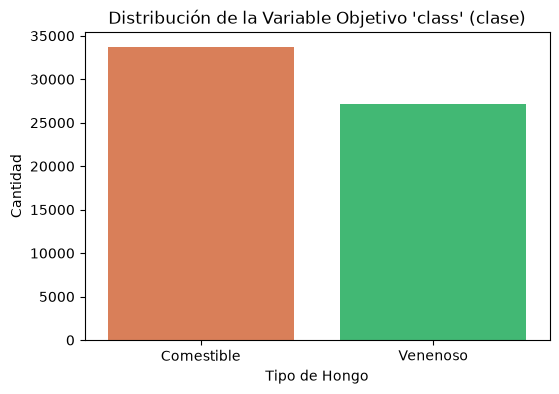

class
Venenoso      55.384666
Comestible    44.615334
Name: proportion, dtype: float64


In [18]:
# Visualización de la distribución de la variable objetivo (class) para analizar el balance entre clases
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', hue='class', palette={'e': '#2ecc71', 'p': '#e74'})
plt.title("Distribución de la Variable Objetivo 'class' (clase)")
plt.xlabel('Tipo de Hongo')
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['Comestible', 'Venenoso']) 
plt.show()
# Cálculo de la distribución relativa de la variable objetivo en porcentaje
class_counts = df['class'].value_counts(normalize=True) * 100
print(class_counts.rename(index={'e': 'Comestible', 'p': 'Venenoso'}))

Esta es la visualización de la distribución de la variable objetivo (class), donde se observa el reparto entre setas comestibles y venenosas. La distribución es bastante equilibrada, con una ligera predominancia de la clase venenosa.

En el análisis porcentual se confirma este comportamiento, mostrando proporciones similares entre ambas clases, por lo que no se aprecia un desbalance significativo que pueda afectar al entrenamiento del modelo en una primera aproximación.

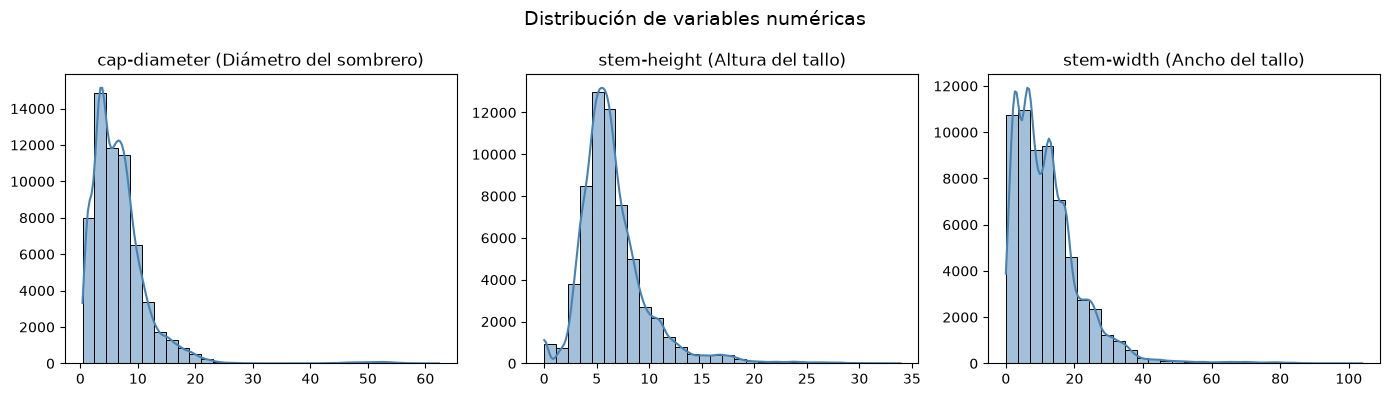

In [19]:
numerical_cols = ["cap-diameter", "stem-height", "stem-width"]

col_names = {
    "cap-diameter": "cap-diameter (Diámetro del sombrero)",
    "stem-height": "stem-height (Altura del tallo)",
    "stem-width": "stem-width (Ancho del tallo)"
}

# Visualización de la distribución de las variables numéricas
plt.figure(figsize=(14, 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], bins=30, kde=True, color="steelblue")
    plt.title(col_names[col])
    plt.xlabel("")
    plt.ylabel("")

plt.suptitle("Distribución de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

Las variables numéricas presentan distribuciones asimétricas, con una alta concentración de valores en rangos bajos y colas largas hacia valores más extremos. Muestran picos pronunciados y presencia de posibles outliers.

En conjunto, estas variables no siguen una distribución normal, por lo que podría ser necesario aplicar técnicas de escalado o transformaciones en etapas posteriores del preprocesamiento para mejorar el rendimiento de los modelos de clasificación.

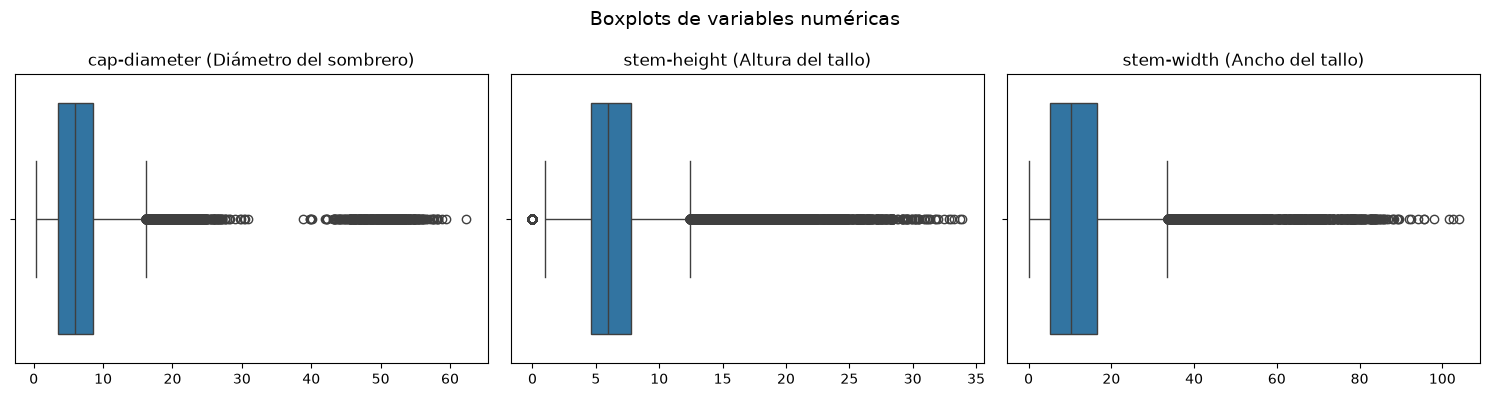

In [20]:
# Visualización de los boxplots de las variables numéricas
plt.figure(figsize=(15, 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col_names[col])
    plt.xlabel("")

plt.suptitle("Boxplots de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

Se visualizan los boxplots de las variables numéricas para analizar su distribución y detectar valores atípicos. Cap-diameter concentra la mayoría de datos entre 0 y 10, con outliers desde ~15 hasta 60. Stem-height se concentra entre 5 y 10, con outliers entre 12 y 35 y algunos valores cercanos a 0. Stem-width presenta mayor dispersión entre 0 y 20, con outliers que alcanzan hasta aproximadamente 100.

En general, todas las variables muestran presencia de outliers relevantes, lo que será importante tener en cuenta en el preprocesamiento.

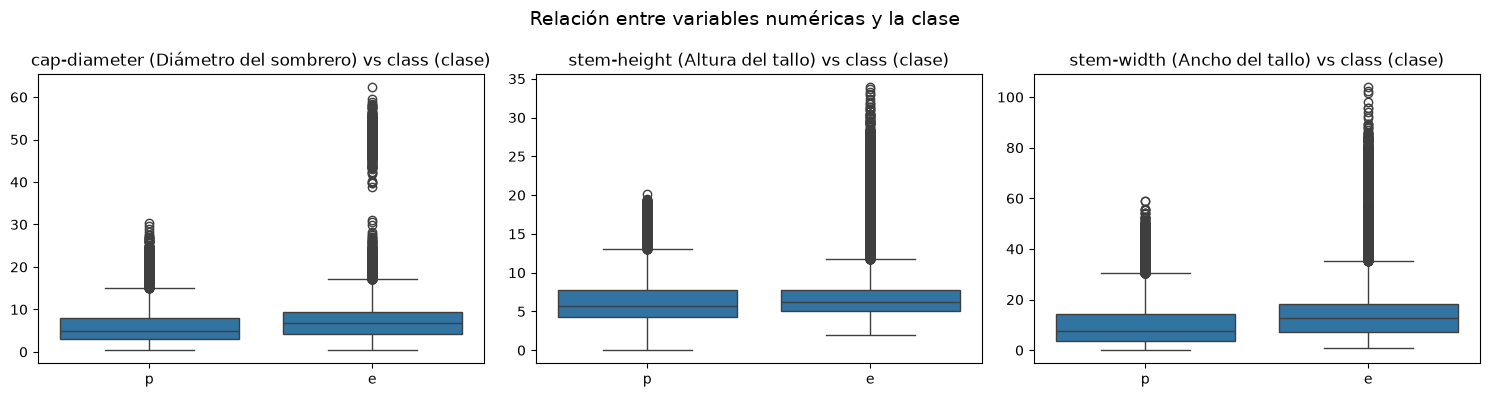

In [21]:
# Visualización de la relación entre variables numéricas y la variable objetivo (class)
plt.figure(figsize=(15, 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, x="class", y=col)
    plt.title(f"{col_names[col]} vs class (clase)")
    plt.xlabel("")
    plt.ylabel("")

plt.suptitle("Relación entre variables numéricas y la clase", fontsize=14)
plt.tight_layout()
plt.show()

Se observa que los outliers varían según la clase. En general, la clase comestible (e) presenta mayor dispersión y rangos más amplios en todas las variables numéricas, especialmente en cap-diameter y stem-width, mientras que la clase venenosa (p) muestra rangos de valores atípicos más reducidos. Esto sugiere diferencias en la variabilidad entre clases que pueden ser relevantes para el modelo de clasificación.

In [22]:
# Se muestran las distribuciones de las variables categóricas para analizar sus valores más frecuentes y detectar posibles patrones o desequilibrios
categorical_cols = df.select_dtypes(include=["object", "string"]).columns
categorical_cols = categorical_cols.drop("class")

for col in categorical_cols:
    print(df[col].value_counts().head(10))
    print("-"*40)

cap-shape
x    26932
f    13404
s     7164
b     5694
o     3316
p     2598
c     1815
Name: count, dtype: int64
----------------------------------------
cap-surface
unknown    14120
t           8184
s           7580
y           6341
h           4974
g           4722
d           4432
e           2584
k           2303
i           2225
Name: count, dtype: int64
----------------------------------------
cap-color
n    24205
y     8541
w     7649
g     4312
e     4035
o     3653
r     1779
u     1709
p     1703
k     1279
Name: count, dtype: int64
----------------------------------------
does-bruise-or-bleed
f    50333
t    10590
Name: count, dtype: int64
----------------------------------------
gill-attachment
a          12697
d          10247
unknown     9855
x           7413
p           6001
e           5648
s           5648
f           3414
Name: count, dtype: int64
----------------------------------------
gill-spacing
unknown    25062
c          24682
d           7765
f           3414


Se observa la distribución de las variables categóricas del dataset. En cap-shape (forma del sombrero) predomina x (convexo), seguido de f (plano) y s (hundido). En cap-color (color del sombrero) destaca n (marrón). En habitat (hábitat) predomina d (bosques). También aparecen valores imputados como unknown en variables como cap-surface (superficie del sombrero) y gill-attachment (tipo de unión de las láminas). En general, las variables presentan distribuciones desbalanceadas con categorías claramente dominantes.

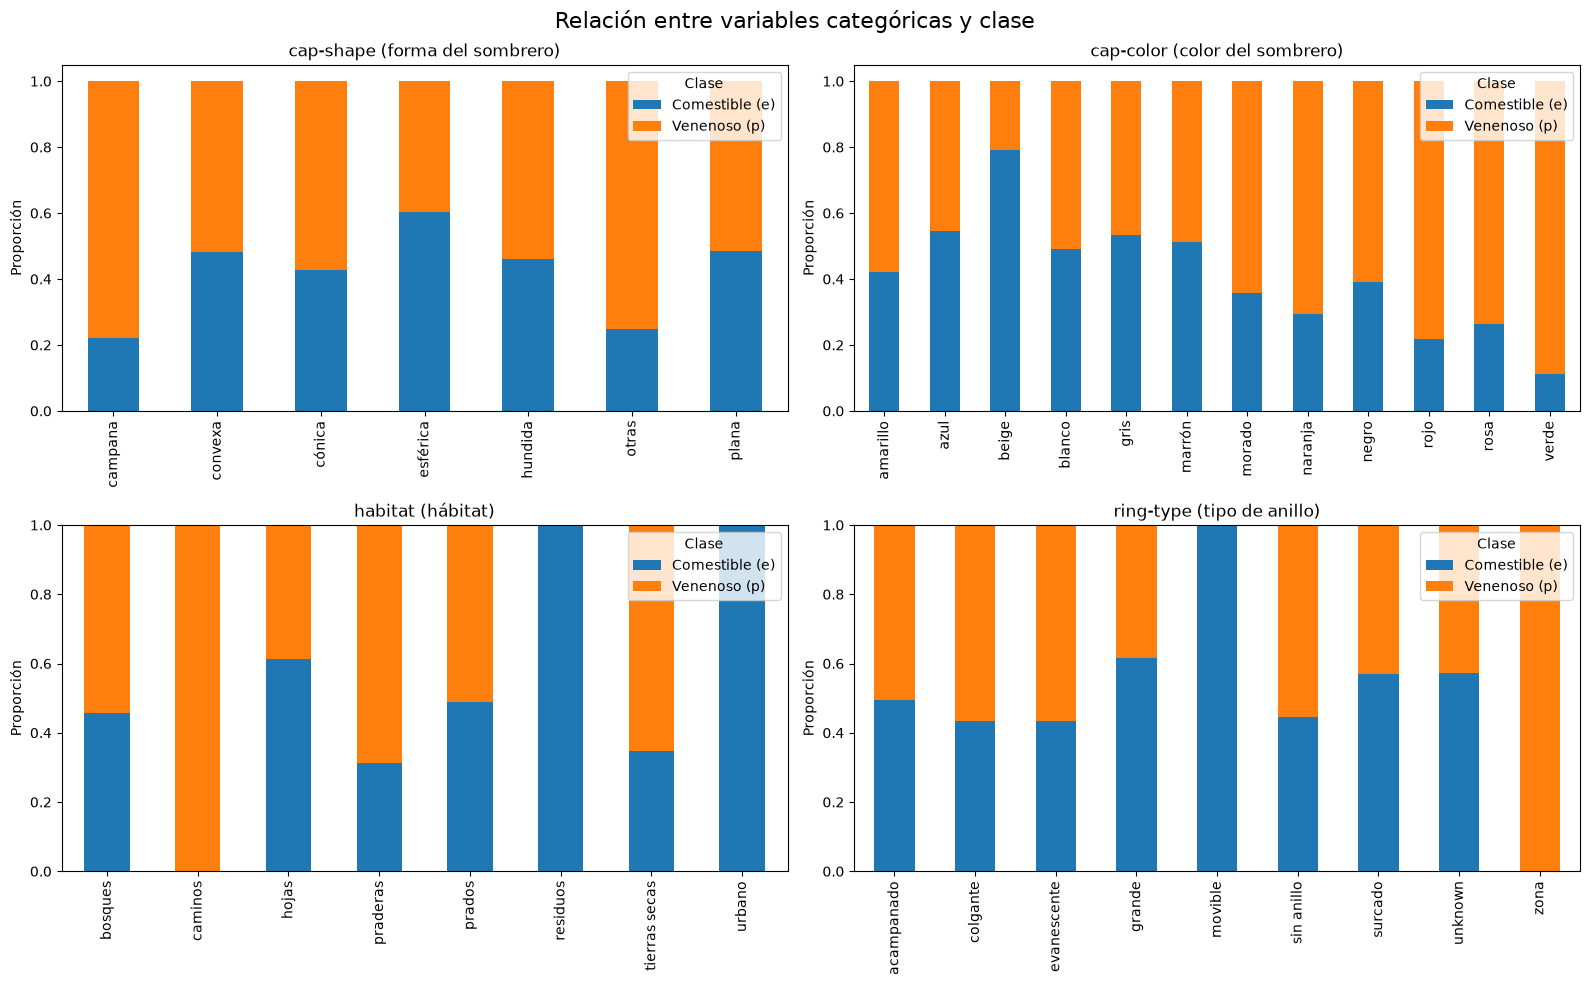

In [23]:
class_names = {"e": "Comestible", "p": "Venenoso"}

# Traducción de variables
col_names = {
    "cap-shape": "cap-shape (forma del sombrero)",
    "cap-surface": "cap-surface (superficie del sombrero)",
    "cap-color": "cap-color (color del sombrero)",
    "does-bruise-or-bleed": "does-bruise-or-bleed (magulladuras/sangrado)",
    "gill-attachment": "gill-attachment (unión de láminas)",
    "gill-spacing": "gill-spacing (espaciado de láminas)",
    "gill-color": "gill-color (color de las láminas)",
    "stem-color": "stem-color (color del tallo)",
    "has-ring": "has-ring (presencia de anillo)",
    "ring-type": "ring-type (tipo de anillo)",
    "habitat": "habitat (hábitat)",
    "season": "season (estación)"
}

# Traducción de categorías
maps = {
    "cap-shape": {
        "b": "campana",
        "c": "cónica",
        "x": "convexa",
        "f": "plana",
        "s": "hundida",
        "p": "esférica",
        "o": "otras"
    },
    "cap-color": {
        "n": "marrón",
        "b": "beige",
        "g": "gris",
        "r": "verde",
        "p": "rosa",
        "u": "morado",
        "e": "rojo",
        "w": "blanco",
        "y": "amarillo",
        "l": "azul",
        "o": "naranja",
        "k": "negro"
    },
    "habitat": {
        "g": "praderas",
        "l": "hojas",
        "m": "prados",
        "p": "caminos",
        "h": "tierras secas",
        "u": "urbano",
        "w": "residuos",
        "d": "bosques"
    },
    "ring-type": {
        "c": "telaraña",
        "e": "evanescente",
        "r": "acampanado",
        "g": "surcado",
        "l": "grande",
        "p": "colgante",
        "s": "envolvente",
        "z": "zona",
        "y": "escamoso",
        "m": "movible",
        "f": "sin anillo"
    }
}

cols = ["cap-shape", "cap-color", "habitat", "ring-type"]

# Visualización de la relación entre variables categóricas y la variable objetivo (class)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):

    df_temp = df.copy()
    df_temp[col] = df_temp[col].replace(maps[col])

    ct = pd.crosstab(df_temp[col], df_temp["class"], normalize="index")

    ct.plot(kind="bar", stacked=True, ax=axes[i])

    axes[i].set_title(col_names[col])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Proporción")
    axes[i].legend(loc="upper right", title="Clase", labels=["Comestible (e)", "Venenoso (p)"])

plt.suptitle("Relación entre variables categóricas y clase", fontsize=16)
plt.tight_layout()
plt.show()

Se observa que la relación entre variables categóricas y la clase no es uniforme. En cap-shape la distribución es relativamente equilibrada, aunque destacan más casos venenosos en formas como campana y más comestibles en formas esféricas. En cap-color se aprecia mayor presencia de venenosos en colores como verde, rojo y naranja, mientras que tonos como beige se asocian más a comestibles. En habitat, algunas categorías como residuos y urbano son mayoritariamente comestibles, mientras que en caminos predomina la clase venenosa. En ring-type, el tipo movible aparece principalmente en comestibles, el tipo zona en venenosos y el resto muestra una distribución más equilibrada.

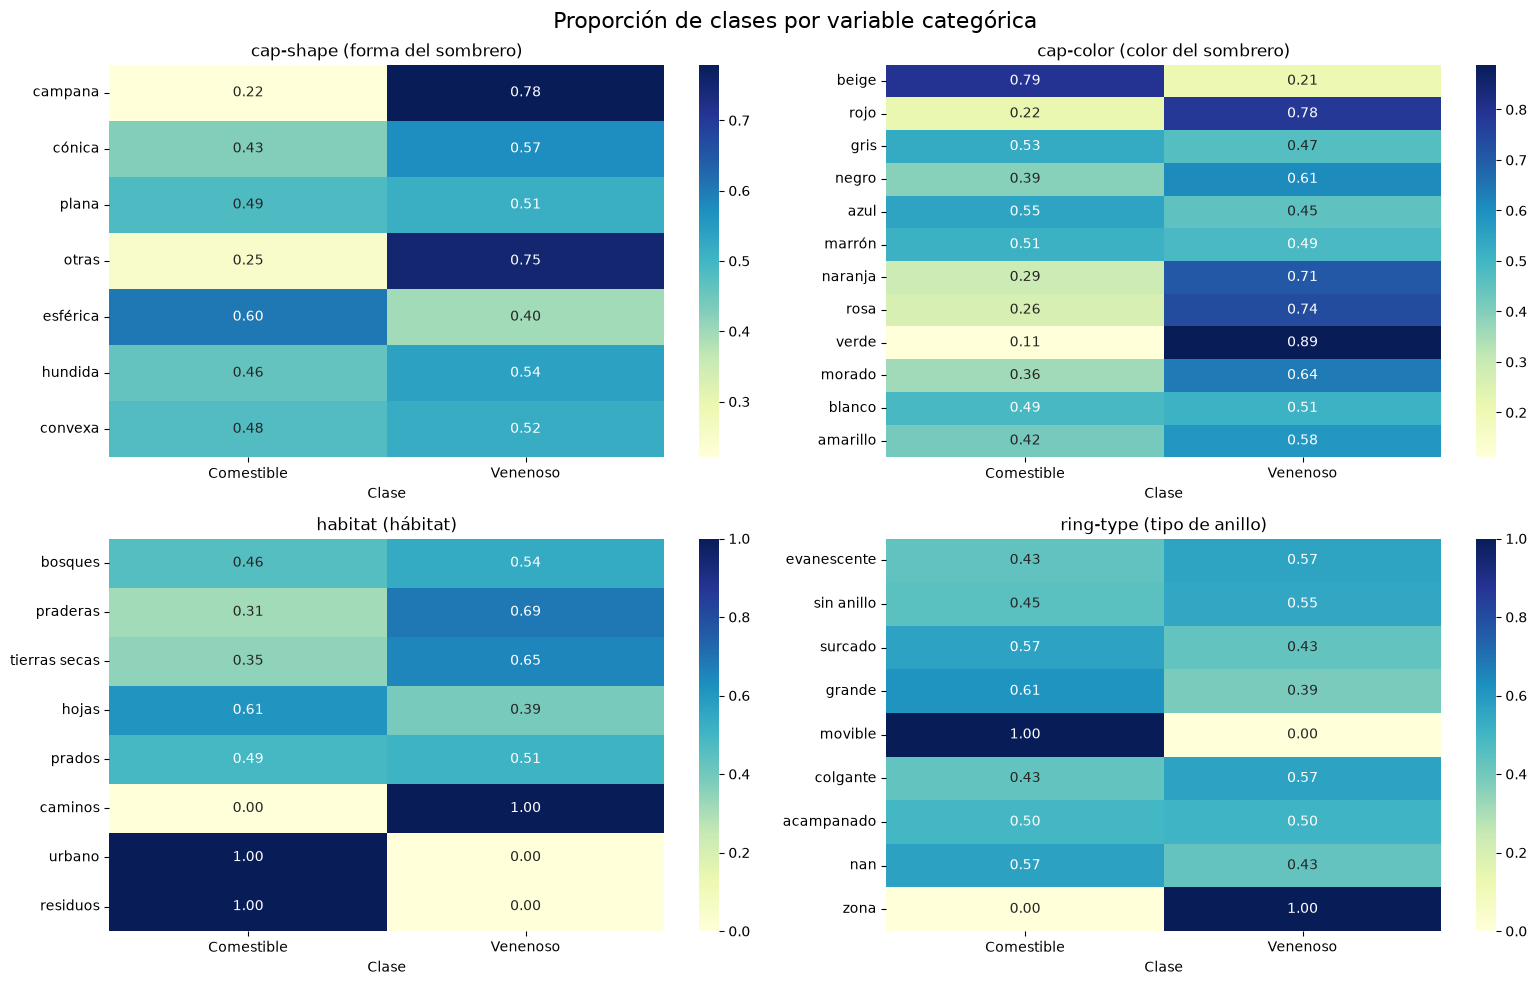

In [24]:
# Visualización de la relación entre variables categóricas y la variable objetivo (class) usando heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):

    # tabla de proporciones
    tabla = pd.crosstab(df[col], df["class"], normalize="index")

    # traducimos categorías usando el diccionario global "maps"
    tabla.index = tabla.index.map(maps[col])

    # traducimos clase
    tabla.columns = tabla.columns.map({"e": "Comestible", "p": "Venenoso"})

    sns.heatmap(tabla, annot=True, cmap="YlGnBu", fmt=".2f", ax=axes[i])

    axes[i].set_title(col_names[col])
    axes[i].set_xlabel("Clase")
    axes[i].set_ylabel("")

plt.suptitle("Proporción de clases por variable categórica", fontsize=16)
plt.tight_layout()
plt.show()

Se observa la relación entre variables categóricas y la clase mediante proporciones normalizadas. Esto permite comparar de forma más clara la distribución de hongos comestibles y venenosos dentro de cada categoría, destacando patrones similares a los vistos anteriormente pero de forma más interpretativa gracias a la normalización por fila.

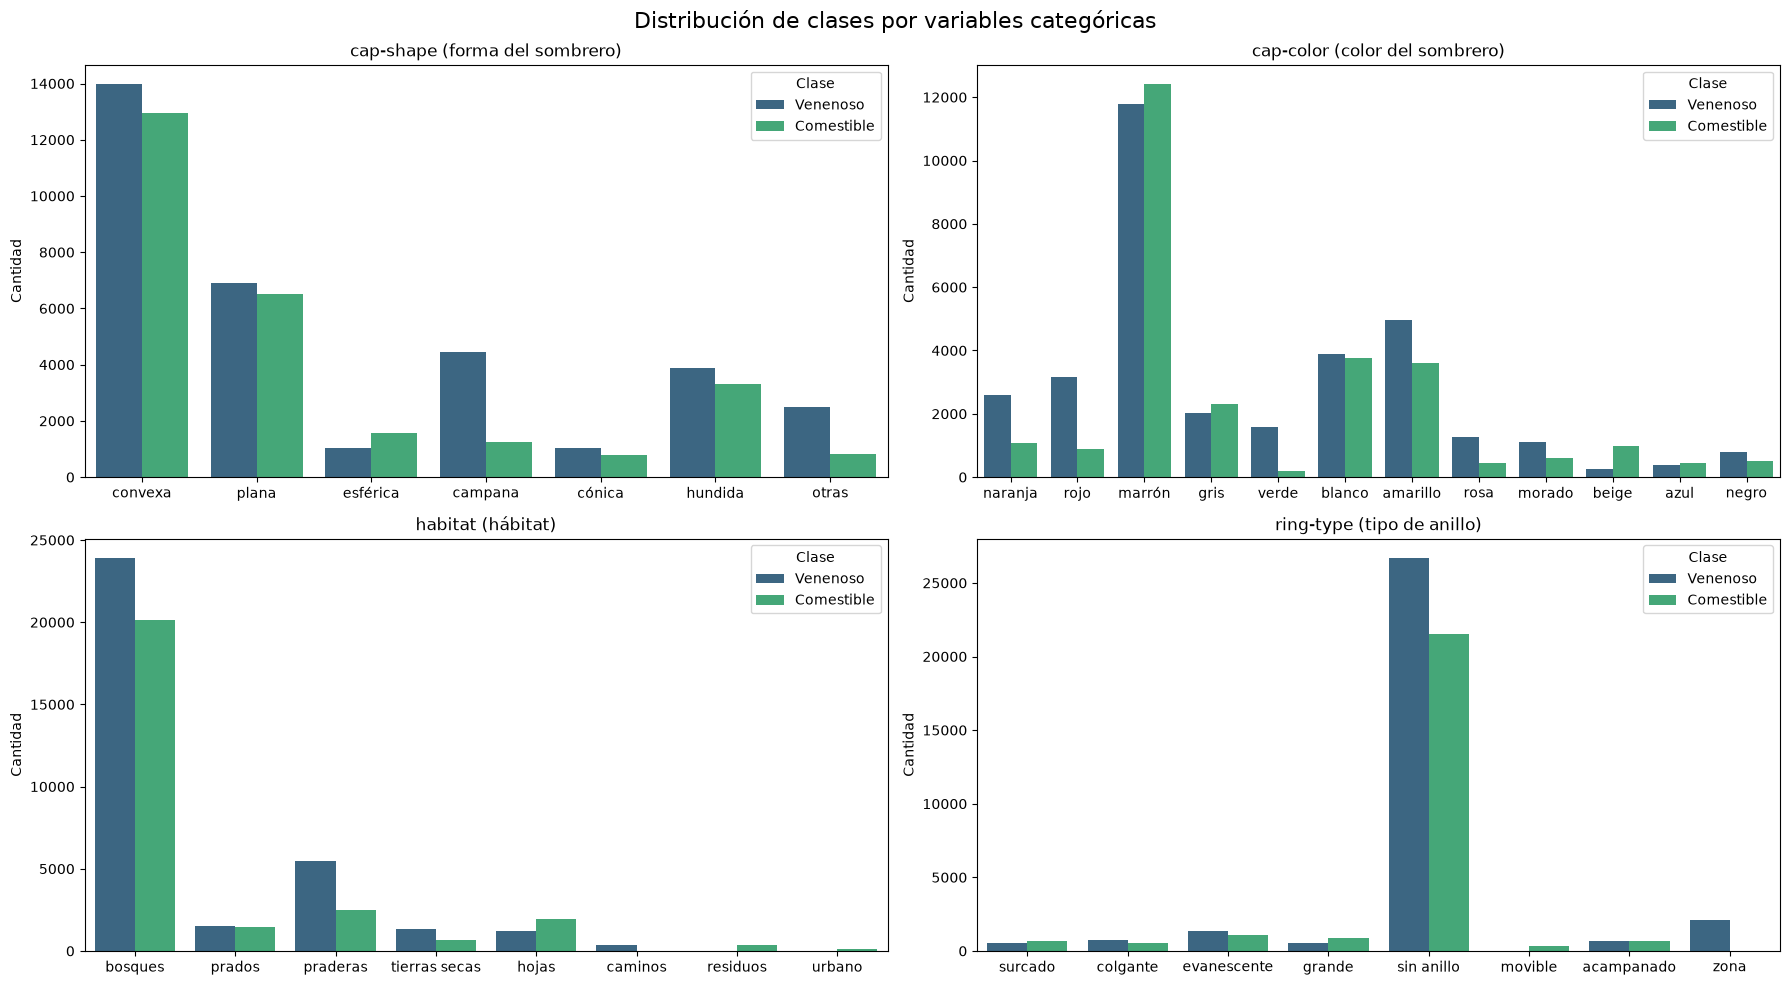

In [25]:
# Visualización de la relación entre variables categóricas y la variable objetivo (class) usando countplots
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols):

    sns.countplot(
        x=df[col].map(maps[col]),
        hue=df["class"].map(class_names),
        palette="viridis",
        ax=axes[i]
    )

    axes[i].set_title(col_names[col])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Cantidad")
    axes[i].legend(title="Clase")

plt.suptitle("Distribución de clases por variables categóricas", fontsize=16)
plt.tight_layout()
plt.show()

Se observa la distribución de las clases por variables categóricas, confirmando los patrones ya vistos en proporciones. Además, se aprecia que en cap-shape predomina la forma convexa, en cap-color el color marrón, en habitat el entorno de bosques y en ring-type la ausencia de anillo es la categoría más frecuente.

In [26]:
# Análisis de la cardinalidad de las variables categóricas
df[categorical_cols].nunique().sort_values(ascending=False)

stem-color              13
cap-surface             12
gill-color              12
cap-color               12
ring-type                9
gill-attachment          8
habitat                  8
cap-shape                7
season                   4
gill-spacing             4
does-bruise-or-bleed     2
has-ring                 2
dtype: int64

Se observa la cantidad de valores únicos en las variables categóricas, lo que permite identificar su cardinalidad. Destacan variables como stem-color, cap-surface, gill-color y cap-color con mayor número de categorías, mientras que otras como has-ring o does-bruise-or-bleed son binarias. Esta información es útil para decidir el tipo de encoding y anticipar la complejidad del modelo.

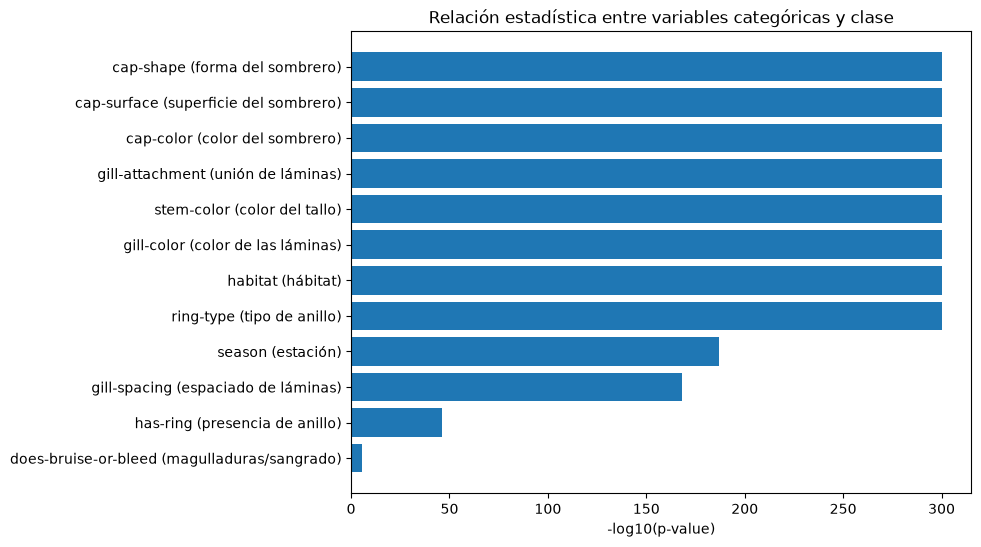

,variable,p_value,log_p
0,cap-shape,0.000000e+00,300.000000
1,cap-surface,0.000000e+00,300.000000
2,cap-color,0.000000e+00,300.000000
4,gill-attachment,0.000000e+00,300.000000
7,stem-color,0.000000e+00,300.000000
6,gill-color,0.000000e+00,300.000000
10,habitat,0.000000e+00,300.000000
9,ring-type,0.000000e+00,300.000000
11,season,7.099388e-188,187.148779
5,gill-spacing,4.514862e-169,168.345356


In [27]:
# Test chi-cuadrado para medir relación entre variables categóricas y la clase

def chi_square_test(df, col, target='class'):
    # Tabla de contingencia entre variable y target
    tabla = pd.crosstab(df[col], df[target])
    
    # Cálculo del test chi-cuadrado
    _, p, _, _ = chi2_contingency(tabla)
    
    # Se devuelve solo el p-value
    return p

# Variables categóricas (excluyendo la target)
variables = categorical_cols

results = pd.DataFrame({
    "variable": variables,
    "p_value": [chi_square_test(df, col) for col in variables]
})

results = results.sort_values("p_value")
results["log_p"] = -np.log10(results["p_value"].replace(0, 1e-300))

plt.figure(figsize=(8, 6))
plt.barh(
    results["variable"].map(lambda x: col_names.get(x, x)),
    results["log_p"]
)

plt.xlabel("-log10(p-value)")
plt.title("Relación estadística entre variables categóricas y clase")
plt.gca().invert_yaxis()
plt.show()

results

La mayoría de variables categóricas muestran una asociación estadísticamente muy significativa con la clase (p-value ≈ 0), lo que indica que tienen un fuerte poder predictivo. Destacan especialmente cap-shape, cap-color, gill-color, habitat y ring-type. Solo does-bruise-or-bleed presenta una relación algo más débil, aunque sigue siendo significativa. En conjunto, el dataset muestra alta separabilidad entre clases a partir de variables categóricas.

## Generación y exportación del dataset final para modelado

In [28]:
# Crear carpeta data si no existe
data_dir = BASE_DIR / "data"
data_dir.mkdir(exist_ok=True)
# Guardar dataset limpio
clean_data_path = data_dir / "mushrooms_clean_secondary.csv"
df.to_csv(clean_data_path, index=False)
print(f"Dataset guardado en: {clean_data_path}")

Dataset guardado en: C:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-project-classification-Grupo-1\data\mushrooms_clean_secondary.csv
